
Con  riferimento  al  data  set  dell’esercitazione  su  clustering,  eseguire  una  classificazione 
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una 
regressione sulla feature aps. 

Procedere  allo  split  train-test  secondo  il  rapporto  95%-15%  in  forma  stratificata 
secondo i valori della variabile target. 

2.Eseguire  l’imputazione  dei  dati  mancanti  con  le  stesse  strategie  dell’esercitazione 
precedente. 

3.Rimuovere  le  feature  che  presentano  elevata  correlazione  con  la  variabile  target  e 
successivamente analizzare le possibili feature multicollineari rimanenti. 

4.Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 

5.Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest

In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset_esercitazione.csv')

df = df.drop(columns=['death','aps'])

X = df.drop(columns=['dzgroup'])
y = df.dzgroup


X_tr , X_te, y_tr, y_te = train_test_split(X,y, test_size=0.15, random_state=42, stratify=df['dzgroup'])

print(df.shape)
print(X_tr.shape)
print(y_tr)

(9105, 41)
(7739, 40)
5189    ARF/MOSF w/Sepsis
3936                 COPD
4587    ARF/MOSF w/Sepsis
6072    ARF/MOSF w/Sepsis
3026    ARF/MOSF w/Sepsis
              ...        
1929                 COPD
7690    ARF/MOSF w/Sepsis
4519    ARF/MOSF w/Sepsis
1803                  CHF
2749                  CHF
Name: dzgroup, Length: 7739, dtype: object


In [2]:
from sklearn.impute import SimpleImputer


imputer1 = SimpleImputer(strategy='median').set_output(transform='pandas')
imputer2 = SimpleImputer(strategy='constant', fill_value='Unknown').set_output(transform='pandas')

num_feature = X_tr.select_dtypes(include=['number']).columns.tolist()
cat_feature = [column for column in X_tr.columns if column not in num_feature]


X_tr_num = imputer1.fit_transform(X_tr[num_feature])
X_tr_cat = imputer2.fit_transform(X_tr[cat_feature])


X_te_num = imputer1.transform(X_te[num_feature]) 
X_te_cat = imputer2.transform(X_te[cat_feature])


In [3]:
from sklearn.preprocessing import OrdinalEncoder


encoder = OrdinalEncoder().set_output(transform='pandas')

X_tr_encode = encoder.fit_transform( X_tr_cat )
X_te_encode = encoder.transform( X_te_cat )

print(X_te_num.shape)
print(X_te_encode.shape)

X_tr_f = pd.concat([X_tr_num , X_tr_encode], axis=1)
X_te_f = pd.concat([X_te_num , X_te_encode], axis=1)


(1366, 34)
(1366, 6)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tr_f[num_feature] = scaler.fit_transform( X_tr_f[num_feature] )
X_te_f[num_feature] = scaler.transform( X_te_f[num_feature] )

In [5]:
corr_matrix = X_tr_f.corr().abs()

threshold = 0.7

num_columns = len(X_tr_f.columns)

for i in range(num_columns):
    for j in range( i+1, num_columns):
        
        valore_corr = corr_matrix.iloc[i,j]
        
        if valore_corr > threshold:
            column_to_delete = corr_matrix.columns[j]
            X_tr = X_tr_f.drop(columns=[column_to_delete])
            X_te = X_te_f.drop(columns=[column_to_delete])
            
            print('Elimino colonna: ', column_to_delete )

Elimino colonna:  totcst
Elimino colonna:  surv2m
Elimino colonna:  surv6m
Elimino colonna:  prg6m
Elimino colonna:  adlsc


In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

select = SelectKBest(f_classif, k=18)

X_tr = select.fit_transform( X_tr , y_tr)
X_te = select.transform(X_te )


/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]]
Migliori parametri trovati: {'criterion': 'log_loss', 'max_features': 5, 'min_samples_split': 2}


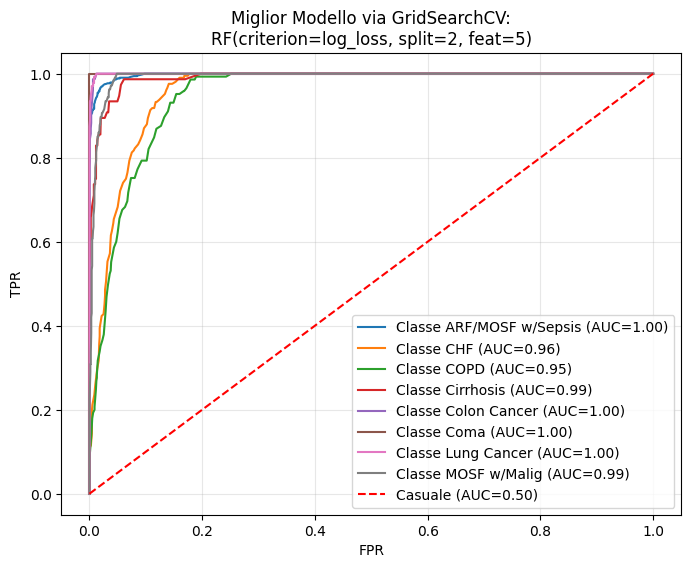

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# 1. Prepariamo le strutture per il multiclasse One-vs-Rest
classi = sorted(list(set(y_tr)))
y_test_binarized = label_binarize(y_te, classes=classi)

print(y_test_binarized)

# 2. Definiamo la griglia come un DIZIONARIO (lo vuole GridSearchCV)
param_grid = {
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}

# 3. Inizializziamo il modello base e la GridSearch
# Nota: usiamo 'roc_auc_ovr_weighted' o 'roc_auc_ovr' come scoring per il multiclasse
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    #scoring='roc_auc_ovr', 
    scoring='roc_auc_ovr_weighted'

)

# 4. Eseguiamo la ricerca (fa tutto da sola: cicli, fit e cross-validation)
grid_search.fit(X_tr, y_tr)

# 5. Estraiamo il vincitore e i suoi parametri 
best_classifier = grid_search.best_estimator_
best_params = grid_search.best_params_
best_params_name = f"RF(criterion={best_params['criterion']}, split={best_params['min_samples_split']}, feat={best_params['max_features']})"

print(f"Migliori parametri trovati: {best_params}")
# ==========================================
# FASE PLOT (Solo per il modello migliore estratto)
# ==========================================
plt.figure(figsize=(8, 6))

# Usiamo il miglior modello estratto per fare le previsioni sul test set
y_best_score = best_classifier.predict_proba(X_te)
print(y_best_score)

# Ciclo classico sulle classi per disegnare le curve ROC
for idx, classe in enumerate(classi):
    y_reale_classe = y_test_binarized[:, idx]
    y_score_classe = y_best_score[:, idx]
    
    auc_cl = roc_auc_score(y_reale_classe, y_score_classe)
    fpr, tpr, _ = roc_curve(y_reale_classe, y_score_classe)
    
    plt.plot(fpr, tpr, label=f"Classe {classe} (AUC={auc_cl:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Casuale (AUC=0.50)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f"Miglior Modello via GridSearchCV:\n{best_params_name}")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

In [11]:
print( y_test_binarized.sum(axis=0) )

[527 208 145  76  77  90 136 107]
